In [1]:
import os
os.environ["WORLD_SIZE"] = "1"
os.environ["RANK"] = "0"
os.environ["LOCAL_RANK"] = "0"
os.environ["MASTER_ADDR"] = "localhost"
os.environ["MASTER_PORT"] = "12355"

# Adding a New Metric to the Benchmarking Workflow

The PhysicsNeMo benchmarking workflow uses a **metric registry** to decouple metrics from models and datasets. Metrics are plain Python functions registered by name — no base class required. When the engine runs, it resolves each metric by name and domain, then calls it with ground truth, predictions, the canonical case, and the comparison mesh.

In this notebook we implement a **side force** metric from scratch. Side force is the aerodynamic force in the lateral (y) direction — the third force component alongside drag (x) and lift (z) that is not included in the default metric set. Computing it requires integrating pressure and wall shear stress over the mesh surface using face normals and areas, so this is a good example of a metric that goes beyond simple array comparisons and accesses mesh geometry directly.

To validate the metric, we also define a **`YSymmetricSineCosine`** dummy model whose predictions are symmetric about the x-z plane. On the nearly y-symmetric DrivAerML car geometries, this symmetry should cause the integrated side force to be approximately zero — a built-in sanity check.

> **Prerequisites**: This notebook assumes familiarity with model wrappers. If you want to understand how the `CFDModel` interface works, see [adding_a_new_model.ipynb](adding_a_new_model.ipynb) first.

## The Metric Registry API

A metric is any callable with signature `(ground_truth, predictions, **kwargs) -> float | dict[str, float]`.

| Function | Purpose |
|----------|--------|
| `register_metric(name, fn, domain=...)` | Register a metric by name. `domain` can be `"surface"`, `"volume"`, or `None` (domain-agnostic). |
| `get_metric(name, domain=...)` | Look up a metric: tries `(name, domain)` first, then `(name, None)` as fallback. |
| `list_metrics()` | Return sorted unique metric names. |

When the engine calls a metric, it passes extended keyword arguments including `case` (the `CanonicalCase`), `comparison_mesh` (PyVista mesh with GT and predicted arrays), `metric_dtype` (`"cell"` or `"point"`), and `output` (field name mappings). If the metric returns a `dict`, keys are auto-flattened: e.g., `{"error": 0.1, "pred": 42.0}` from a metric named `side_force` becomes `side_force_error` and `side_force_pred` in the results.

## Implementing the Side Force Metric

The aerodynamic force on a surface in a given direction **d** has two contributions:

- **Pressure force**: each face contributes `p * (n · d) * A`, where `p` is pressure, `n` is the outward face normal, and `A` is the face area.
- **Viscous (skin friction) force**: each face contributes `-(wss · d) * A`, where `wss` is the wall shear stress vector.

The total force coefficient is `C = coeff * (pressure_force + viscous_force)`, where `coeff` is typically `2 / (ρ U² A_ref)`.

For **side force**, we set `d = [0, 1, 0]` (the y-direction). This is exactly the same computation that the built-in `drag` and `lift` metrics use with `d = [1, 0, 0]` and `d = [0, 0, 1]` respectively (see `physicsnemo.cfd.postprocessing_tools.metrics.aero_forces.compute_force_coefficients`).

Below we implement it from scratch so you can see every step.

In [2]:
import numpy as np
import pyvista as pv


def compute_side_force(
    mesh,
    pressure_field: str,
    wss_field: str,
    force_direction: list[float] | np.ndarray = (0.0, 1.0, 0.0),
    coeff: float = 1.0,
    dtype: str = "cell",
) -> tuple[float, float, float]:
    """Compute the force coefficient in an arbitrary direction from a surface mesh.

    Returns (c_total, c_pressure, c_friction).
    """
    d = np.asarray(force_direction, dtype=np.float64)

    if dtype == "cell":
        mesh = mesh.compute_normals()
        mesh = mesh.compute_cell_sizes()
        normals = mesh["Normals"]
        areas = mesh["Area"]
        p = mesh.cell_data[pressure_field]
        wss = mesh.cell_data[wss_field]
    elif dtype == "point":
        normals = -1.0 * np.stack(
            [mesh.point_data["normal_x"], mesh.point_data["normal_y"], mesh.point_data["normal_z"]], axis=1,
        )
        areas = mesh.point_data["area"]
        p = mesh.point_data[pressure_field]
        wss = mesh.point_data[wss_field]
    else:
        raise ValueError(f"dtype must be 'cell' or 'point', got {dtype!r}")

    n_dot_d = np.dot(normals, d)
    c_pressure = coeff * np.sum(n_dot_d * areas * p)
    c_friction = -coeff * np.sum(np.dot(wss, d) * areas)
    c_total = c_pressure + c_friction

    return float(c_total), float(c_pressure), float(c_friction)


print("compute_side_force defined.")

compute_side_force defined.


## Wrapping as a Registered Metric

Now we wrap `compute_side_force` into a metric function that matches the engine's calling convention — the same pattern used by the built-in `drag` and `lift` metrics in `physicsnemo.cfd.evaluation.metrics.builtin.forces`. The metric returns a dict with `error`, `true`, and `pred` sub-keys.

In [ ]:
from typing import Any
from physicsnemo.cfd.postprocessing_tools.metric_registry import register_metric
from physicsnemo.cfd.evaluation.metrics.mesh_bridge import (
    resolve_comparison_mesh_for_metric,
)


def side_force_metric(
    ground_truth: dict,
    predictions: dict,
    *,
    case: Any = None,
    comparison_mesh: Any = None,
    metric_dtype: str | None = None,
    output: Any = None,
    coeff: float = 1.0,
    force_direction: list[float] | None = None,
    **_: object,
) -> dict[str, float]:
    """Side force metric: force coefficient in an arbitrary direction (default y)."""
    d = force_direction if force_direction is not None else [0.0, 1.0, 0.0]

    mesh, dtype = resolve_comparison_mesh_for_metric(
        predictions, case=case, comparison_mesh=comparison_mesh,
        metric_dtype=metric_dtype, output=output,
    )
    if mesh is None or output is None:
        return {"error": float("nan"), "true": float("nan"), "pred": float("nan")}

    gtp = output.ground_truth_mesh_field_names["pressure"]
    gtw = output.ground_truth_mesh_field_names["shear_stress"]
    prp = output.mesh_field_names["pressure"]
    prw = output.mesh_field_names["shear_stress"]

    try:
        cy_gt, _, _ = compute_side_force(mesh, gtp, gtw, force_direction=d, coeff=coeff, dtype=dtype)
        cy_pr, _, _ = compute_side_force(mesh, prp, prw, force_direction=d, coeff=coeff, dtype=dtype)
    except Exception:
        return {"error": float("nan"), "true": float("nan"), "pred": float("nan")}

    denom = abs(cy_gt)
    rel = abs(cy_pr - cy_gt) / denom if denom > 1e-14 else abs(cy_pr - cy_gt)
    return {"error": float(rel), "true": float(cy_gt), "pred": float(cy_pr)}


register_metric("side_force", side_force_metric, domain="surface")
print("Registered 'side_force' metric (domain='surface').")

Warp DeprecationWarning: The namespace `warp.context` will soon be removed from the public API. It can still be accessed from `warp._src.context` but might be changed or removed without notice.
Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Registered 'side_force' metric (domain='surface').


## Defining the YSymmetricSineCosine Model

To validate the side force metric, we need a model whose predictions are **symmetric about the x-z plane** (y = 0). On the nearly y-symmetric DrivAerML car geometries, this should produce a side force very close to zero.

The key design choices:

- **Pressure** depends on `y²` (not `y`), making it an **even function** of y: `p(x, -y, z) = p(x, y, z)`. So pressure × normal_y integrates to ~0 because positive and negative y-faces see the same pressure but opposite normals.
- **WSS y-component** is proportional to `y * cos(...)`, making it **odd** in y: `wss_y(x, -y, z) = -wss_y(x, y, z)`. So the viscous y-force also cancels by symmetry.
- **WSS x- and z-components** use `y²` (even), so they don't break the symmetry.

For details on how model wrappers work, see [adding_a_new_model.ipynb](adding_a_new_model.ipynb).

In [ ]:
import torch
from typing import ClassVar
import pyvista as pv

from physicsnemo.cfd.evaluation.models.model_registry import (
    CFDModel, register_model, OutputLocation,
)
from physicsnemo.cfd.evaluation.datasets.schema import (
    CanonicalCase, InferenceDomain, build_predictions_dict,
)
from physicsnemo.cfd.evaluation.inference.progress import log_inference


class YSymmetricSineCosineWrapper(CFDModel):
    """Dummy model with y-symmetric predictions for side force validation.

    Pressure uses y**2 (even in y). WSS y-component uses y (odd in y).
    On y-symmetric geometry, the integrated side force should be ~0.
    """

    INFERENCE_DOMAIN: ClassVar[InferenceDomain] = "surface"
    OUTPUT_LOCATION: ClassVar[OutputLocation] = "cell"

    def __init__(self) -> None:
        self._weights: dict[str, torch.Tensor] | None = None
        self._device: str = "cpu"

    @property
    def output_location(self) -> OutputLocation:
        return self.OUTPUT_LOCATION

    def load(self, checkpoint_path, stats_path, device, **kwargs):
        self._device = device
        self._weights = torch.load(checkpoint_path, map_location=device, weights_only=True)
        log_inference("y_sym_sine_cosine", f"Loaded {len(self._weights)} parameters")
        return self

    def prepare_inputs(self, case: CanonicalCase) -> torch.Tensor:
        mesh = pv.read(case.mesh_path)
        if not isinstance(mesh, pv.PolyData):
            mesh = mesh.extract_surface()
        coords = np.array(mesh.cell_centers().points, dtype=np.float32)
        log_inference("y_sym_sine_cosine", f"Prepared {coords.shape[0]} coordinates for {case.case_id}")
        return torch.tensor(coords, device=self._device)

    def predict(self, model_input: torch.Tensor) -> dict[str, torch.Tensor]:
        w = self._weights
        x, y, z = model_input[:, 0], model_input[:, 1], model_input[:, 2]
        y2 = y * y

        # Pressure: even in y (depends on y**2)
        pressure = (
            w["p_scale"]
            * torch.sin(w["p_freq_lo"] * (x + y2 + z))
            * torch.cos(w["p_freq_hi"] * x)
            * torch.sin(w["p_freq_hi"] * z)
            + w["p_bias"]
        )

        # WSS x,z: even in y (use y**2)
        wss_x = w["wss_scale"] * torch.sin(w["wss_freq_lo"] * x) * torch.cos(w["wss_freq_hi"] * (y2 + z))
        wss_z = w["wss_scale"] * torch.cos(w["wss_freq_lo"] * z) * torch.sin(w["wss_freq_hi"] * (x + y2))
        # WSS y: odd in y (proportional to y) — cancels on symmetric geometry
        wss_y = w["wss_scale"] * y * torch.cos(w["wss_freq_hi"] * (x + z))
        wss = torch.stack([wss_x, wss_y, wss_z], dim=1)

        log_inference("y_sym_sine_cosine", "Forward pass complete.")
        return {"pressure": pressure, "shear_stress": wss}

    def decode_outputs(self, raw_output, case):
        return build_predictions_dict(
            pressure=raw_output["pressure"].cpu().numpy(),
            shear_stress=raw_output["shear_stress"].cpu().numpy(),
        )


register_model("y_sym_sine_cosine", YSymmetricSineCosineWrapper)
print("Registered 'y_sym_sine_cosine' model wrapper.")

/usr/local/lib/python3.12/dist-packages/torch/library.py:357: UserWarning: Warning only once for all operators,  other operators may also be overridden.
  Overriding a previously registered kernel for the same operator and the same dispatch key
  operator: flash_attn::_flash_attn_backward(Tensor dout, Tensor q, Tensor k, Tensor v, Tensor out, Tensor softmax_lse, Tensor(a6!)? dq, Tensor(a7!)? dk, Tensor(a8!)? dv, float dropout_p, float softmax_scale, bool causal, SymInt window_size_left, SymInt window_size_right, float softcap, Tensor? alibi_slopes, bool deterministic, Tensor? rng_state=None) -> Tensor
    registered at /usr/local/lib/python3.12/dist-packages/torch/_library/custom_ops.py:926
  dispatch key: ADInplaceOrView
  previous kernel: no debug info
       new kernel: registered at /usr/local/lib/python3.12/dist-packages/torch/_library/custom_ops.py:926 (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/core/dispatch/OperatorEntry.cpp:208.)
  self.m.impl(
/workspace/aero-

Registered 'y_sym_sine_cosine' model wrapper.


## Creating Dummy Weights and Loading Data

In [5]:
import tempfile
import json

weights = {
    "p_scale": torch.tensor(200.0),
    "p_freq_lo": torch.tensor(0.8),
    "p_freq_hi": torch.tensor(3.0),
    "p_bias": torch.tensor(-50.0),
    "wss_scale": torch.tensor(8.0),
    "wss_freq_lo": torch.tensor(1.2),
    "wss_freq_hi": torch.tensor(4.0),
}

CKPT_DIR = tempfile.mkdtemp(prefix="y_sym_model_")
CKPT_PATH = os.path.join(CKPT_DIR, "checkpoint.pt")
STATS_PATH = os.path.join(CKPT_DIR, "global_stats.json")

torch.save(weights, CKPT_PATH)
with open(STATS_PATH, "w") as f:
    json.dump({"mean": {"pressure": [0.0], "shear_stress": [0.0, 0.0, 0.0]},
               "std_dev": {"pressure": [1.0], "shear_stress": [1.0, 1.0, 1.0]}}, f)

print(f"Checkpoint: {CKPT_PATH}")
print(f"Parameters: {list(weights.keys())}")

Checkpoint: /tmp/y_sym_model_ooyw6r0_/checkpoint.pt
Parameters: ['p_scale', 'p_freq_lo', 'p_freq_hi', 'p_bias', 'wss_scale', 'wss_freq_lo', 'wss_freq_hi']


In [6]:
from physicsnemo.cfd.evaluation.datasets.adapters.drivaerml import DrivAerMLAdapter

DRIVAERML_ROOT = "/lustre/fsw/coreai_modulus_cae/datasets/drivaer_aws/drivaer_data_finetune"
INFERENCE_CASES = ["run_1", "run_11"]

adapter = DrivAerMLAdapter(root=DRIVAERML_ROOT, inference_domain="surface")
case = adapter.load_case(INFERENCE_CASES[0])
print(f"Case {case.case_id}: {case.mesh_path}")
print(f"GT keys: {list(case.ground_truth.keys()) if case.ground_truth else 'None'}")

[dataset:drivaerml] load_case('run_1'): branch='surface', root=/lustre/fsw/coreai_modulus_cae/datasets/drivaer_aws/drivaer_data_finetune


[dataset:drivaerml] Reading surface mesh from /lustre/fsw/coreai_modulus_cae/datasets/drivaer_aws/drivaer_data_finetune/run_1/boundary_1.vtp


Case run_1: /lustre/fsw/coreai_modulus_cae/datasets/drivaer_aws/drivaer_data_finetune/run_1/boundary_1.vtp
GT keys: ['pressure', 'shear_stress']


## Running Inference and Computing Side Force

Let's run the y-symmetric model, then compute the side force directly to verify it is close to zero.

In [7]:
import time

wrapper = YSymmetricSineCosineWrapper()
wrapper.load(checkpoint_path=CKPT_PATH, stats_path=STATS_PATH, device="cuda:0")

start = time.time()
model_input = wrapper.prepare_inputs(case)
raw_output = wrapper.predict(model_input)
predictions = wrapper.decode_outputs(raw_output, case)
elapsed = time.time() - start

print(f"Inference on {case.case_id}: {elapsed:.3f}s")
for k, v in predictions.items():
    print(f"  {k}: shape={v.shape}, range=[{v.min():.4f}, {v.max():.4f}]")

[inference:y_sym_sine_cosine] Loaded 7 parameters


[inference:y_sym_sine_cosine] Prepared 8828095 coordinates for run_1


[inference:y_sym_sine_cosine] Forward pass complete.


Inference on run_1: 4.762s
  pressure: shape=(8828095,), range=[-243.4638, 118.2938]
  shear_stress: shape=(8828095, 3), range=[-8.0000, 8.0000]


In [ ]:
import pyvista as pv
vis_mesh = pv.read(case.mesh_path)
vis_mesh.cell_data["pMeanTrimPred"] = predictions["pressure"]
vis_mesh.cell_data["wallShearStressMeanTrimPred"] = predictions["shear_stress"]

cd_pred, cd_p, cd_f = compute_side_force(
    vis_mesh, "pMeanTrimPred", "wallShearStressMeanTrimPred",
    force_direction=[1.0, 0.0, 0.0], dtype="cell",
)
cl_pred, cl_p, cl_f = compute_side_force(
    vis_mesh, "pMeanTrimPred", "wallShearStressMeanTrimPred",
    force_direction=[0.0, 0.0, 1.0], dtype="cell",
)
cy_pred, cy_p, cy_f = compute_side_force(
    vis_mesh, "pMeanTrimPred", "wallShearStressMeanTrimPred",
    force_direction=[0.0, 1.0, 0.0], dtype="cell",
)

print(f"Drag force  (x):  Cd = {cd_pred:.6e}  (pressure: {cd_p:.6e}, friction: {cd_f:.6e})")
print(f"Lift force  (z):  Cl = {cl_pred:.6e}  (pressure: {cl_p:.6e}, friction: {cl_f:.6e})")
print(f"Side force  (y):  Cy = {cy_pred:.6e}  (pressure: {cy_p:.6e}, friction: {cy_f:.6e})")
print(f"\nDrag and lift should be substantial; side force should be closer to zero.")

Drag force  (x):  Cd = -3.275685e+00  (pressure: 3.242925e+01, friction: -3.570493e+01)
Lift force  (z):  Cl = -6.812958e+01  (pressure: -3.590343e+01, friction: -3.222615e+01)
Side force  (y):  Cy = -9.865301e-01  (pressure: -1.335655e-01, friction: -8.529645e-01)

Drag and lift should be substantial; side force should be closer to zero.


## Visualization

/workspace/aero-benchmarking/physicsnemo-cfd/physicsnemo/cfd/postprocessing_tools/visualization/utils.py:26: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk with osmesa instead.
  pv.start_xvfb()


/tmp/ipykernel_2991241/275938331.py:4: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk with osmesa instead.
  pv.start_xvfb()


2026-04-22 12:31:40.290 (  50.025s) [    7FFFF7C73540]    vtkX11Functions.cxx:194   WARN| Failed to load Xcursor library
2026-04-22 12:31:40.368 (  50.103s) [    7FFFF7C73540]    vtkX11Functions.cxx:194   WARN| Failed to load Xcursor library


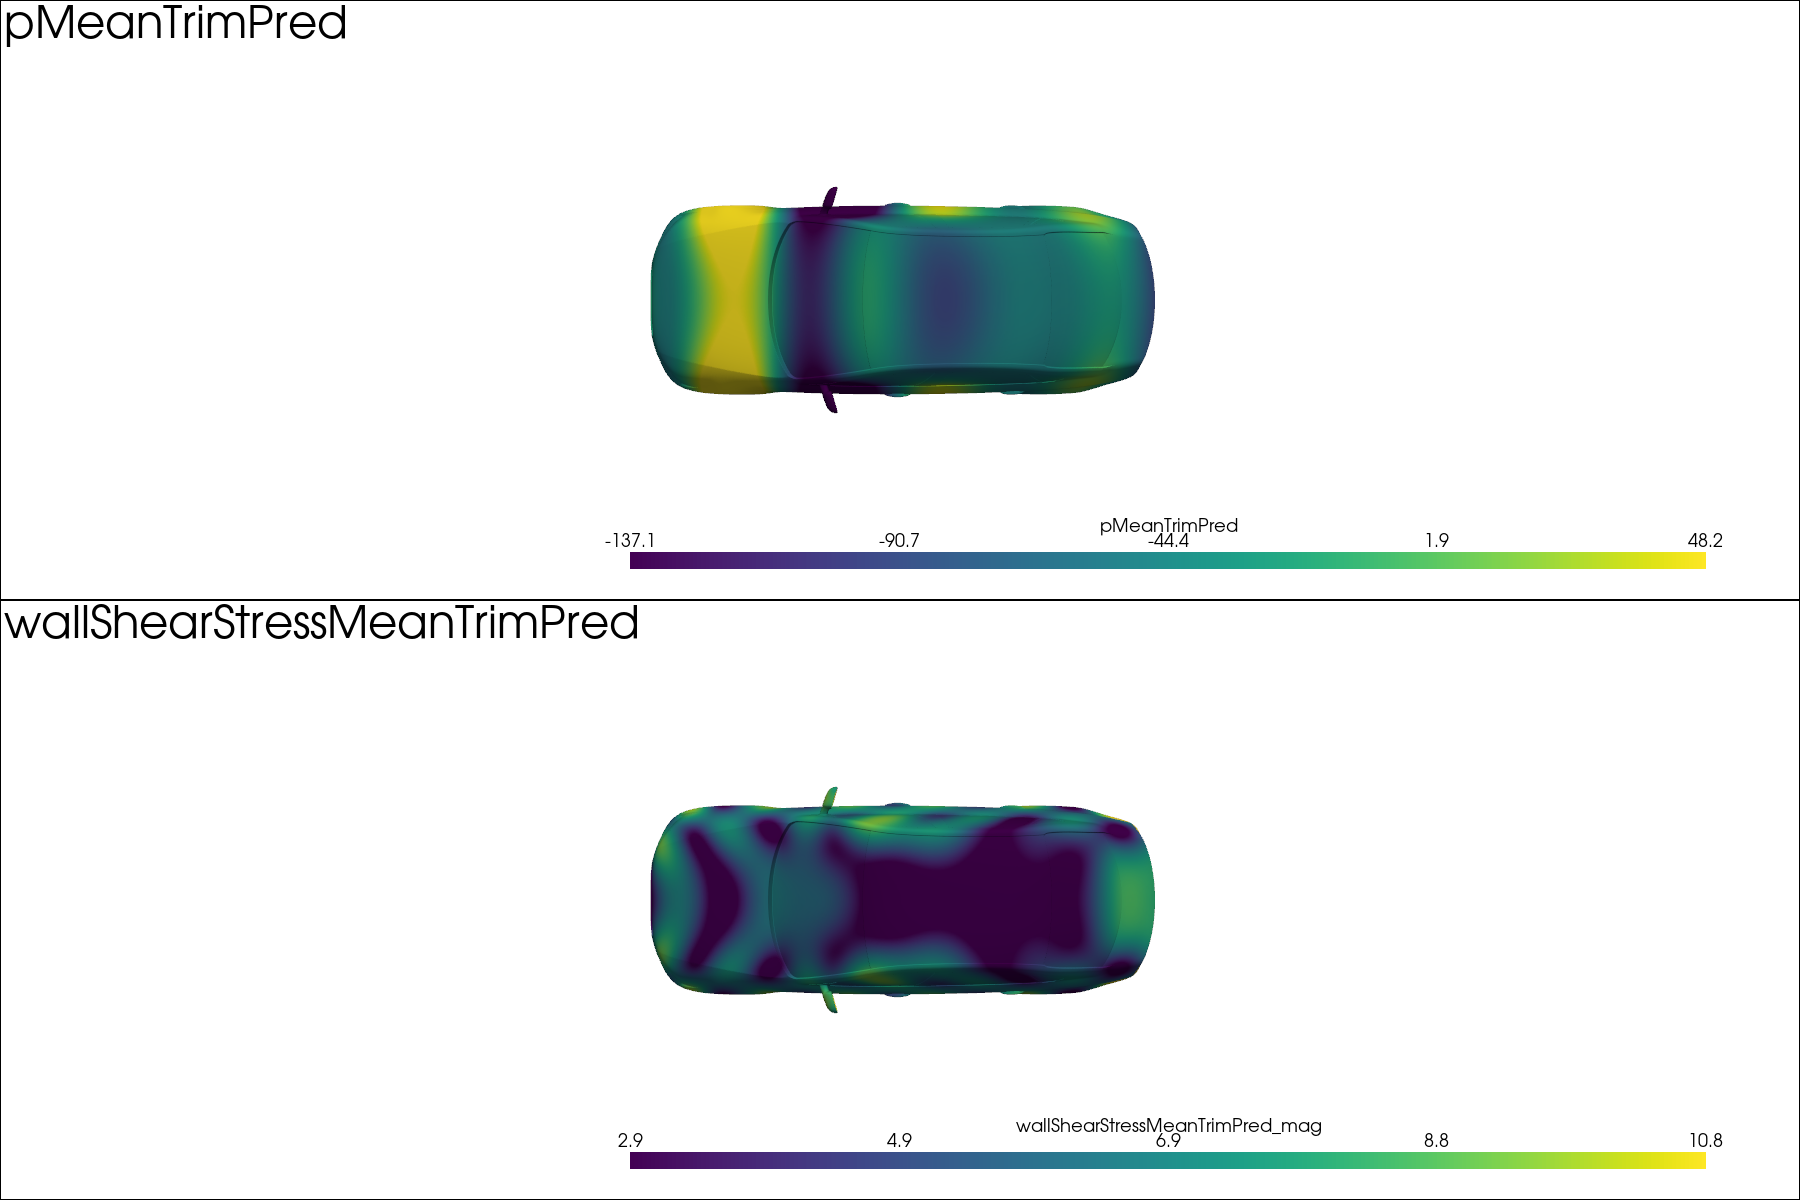

In [9]:
from physicsnemo.cfd.postprocessing_tools.visualization.utils import plot_fields
from IPython.display import Image, display

_xvfb = getattr(pv, "start_xvfb", None)
if _xvfb is not None:
    _xvfb()
else:
    pv.OFF_SCREEN = True
os.makedirs("side_force_benchmark_results", exist_ok=True)

plotter = plot_fields(
    vis_mesh,
    fields=["pMeanTrimPred", "wallShearStressMeanTrimPred"],
    view="xy", dtype="cell", window_size=[1800, 1200],
)
img_path = "side_force_benchmark_results/y_sym_predicted_fields.png"
plotter.screenshot(img_path)
plotter.close()
display(Image(filename=img_path))

## Running the Full Benchmark

With both the metric and model registered, we can run the full benchmarking engine. The `side_force` metric will appear in the results alongside the standard L2 and force metrics.

In [10]:
from physicsnemo.cfd.evaluation.config import Config
from physicsnemo.cfd.evaluation.benchmarks.engine import run_benchmark

config = Config.from_dict({
    "run": {
        "device": "cuda:0",
        "output_dir": "side_force_benchmark_results",
        "save_inference_mesh": False,
        "metrics_cache": {"enabled": False},
    },
    "benchmark": {
        "mode": "matrix",
        "models": [{
            "name": "y_sym_sine_cosine",
            "inference_domain": "surface",
            "checkpoint": CKPT_PATH,
            "stats_path": STATS_PATH,
            "kwargs": {},
        }],
        "datasets": [{
            "name": "drivaerml",
            "root": DRIVAERML_ROOT,
            "case_ids": INFERENCE_CASES,
            "kwargs": {"align_ground_truth_to_model": True, "inference_domain": "surface"},
        }],
        "reproducibility": {"log_env": False, "save_artifacts": True},
    },
    "output": {
        "mesh_field_names": {"pressure": "pMeanTrimPred", "shear_stress": "wallShearStressMeanTrimPred"},
    },
    "metrics": [
        "l2_pressure",
        "l2_shear_stress",
        "drag",
        "lift",
        "side_force",
    ],
    "reports": {"enabled": False},
})

print("Running benchmark with side_force metric...")
results = run_benchmark(config)
print("Benchmark complete.")

Running benchmark with side_force metric...


[dataset:benchmark] Distributed: rank 0/1 (no case sharding).


[dataset:drivaerml] Listing cases under root '/lustre/fsw/coreai_modulus_cae/datasets/drivaer_aws/drivaer_data_finetune' (split=None)…


[dataset:drivaerml] Loading 2 case(s) from root '/lustre/fsw/coreai_modulus_cae/datasets/drivaer_aws/drivaer_data_finetune' (model 'y_sym_sine_cosine')…


[inference:y_sym_sine_cosine] Loaded 7 parameters


...

[dataset:benchmark] Writing benchmark reports to side_force_benchmark_results (formats: json, csv, html)…


[dataset:benchmark] Writing side_force_benchmark_results/benchmark_results.json…


[dataset:benchmark] Writing side_force_benchmark_results/benchmark_results.csv…


[dataset:benchmark] Writing side_force_benchmark_results/benchmark_results.html…


Benchmark complete.


## Inspecting Results

In [11]:
results_path = "side_force_benchmark_results/benchmark_results.json"
with open(results_path) as f:
    report = json.load(f)

for combo in report:
    print(f"\n{'='*60}")
    print(f"Model: {combo['model']}  |  Dataset: {combo['dataset']}")
    print(f"{'='*60}")

    metrics = combo.get("metrics", {})
    for name, val in sorted(metrics.items()):
        if isinstance(val, float):
            print(f"  {name:35s} {val:.6e}")
        else:
            print(f"  {name:35s} {val}")

    per_case = combo.get("per_case", [])
    if per_case:
        print(f"\n  Per-case ({len(per_case)} cases):")
        for pc in per_case:
            print(f"    {pc['case_id']}:")
            for mk, mv in sorted(pc.get("metrics", {}).items()):
                if isinstance(mv, float):
                    print(f"      {mk:33s} {mv:.6e}")

print(f"\nNote: side_force_pred should be close to zero (y-symmetric fields on nearly y-symmetric geometry).")
print(f"Full results: {results_path}")


Model: y_sym_sine_cosine  |  Dataset: drivaerml
  drag_error                          1.062344e+00
  drag_pred                           -3.512814e+01
  drag_true                           5.382742e+02
  l2_pressure                         9.021504e-01
  l2_shear_stress_wallShearStressMean_x_l2_error 1.681195e+00
  l2_shear_stress_wallShearStressMean_y_l2_error 3.025512e+00
  l2_shear_stress_wallShearStressMean_z_l2_error 4.707532e+00
  lift_error                          1.452190e+00
  lift_pred                           -6.688514e+01
  lift_true                           1.642016e+02
  side_force_error                    1.005477e+00
  side_force_pred                     -4.324728e-01
  side_force_true                     8.484181e+01

  Per-case (2 cases):
    run_1:
      drag_error                        1.006420e+00
      drag_pred                         -3.275685e+00
      drag_true                         5.102009e+02
      l2_pressure                       9.132429e-01
     

## Next Steps

That completes the custom metric tutorial. We implemented a side force metric from scratch — computing face normals, areas, and integrating pressure and shear stress projections — registered it with the metric registry, validated it using y-symmetric predictions on nearly y-symmetric geometry, and ran it through the full benchmarking engine.

To summarize the steps for adding a custom metric:

1. **Write a function** with signature `(ground_truth, predictions, **kwargs) -> float | dict[str, float]`
2. **Accept extended kwargs** (`case`, `comparison_mesh`, `metric_dtype`, `output`) for mesh-based metrics
3. **Register** with `register_metric("my_metric", fn, domain="surface")` (or `"volume"` or `None`)
4. **Add to config**: include `"my_metric"` in the `metrics` list

To make the metric permanent, add it to `physicsnemo/cfd/evaluation/metrics/builtin/` and call `register_metric` from the `register_all_builtin_metrics()` chain in `builtin/__init__.py`.

The same `compute_side_force` function we wrote here uses the exact same physics as the built-in `compute_force_coefficients` in `physicsnemo.cfd.postprocessing_tools.metrics.aero_forces` — the only difference is the force direction vector. For drag it's `[1, 0, 0]`, for lift it's `[0, 0, 1]`, and for side force it's `[0, 1, 0]`.